# Analyse trail — course réelle vs courbes théoriques

Ce notebook compare le profil d'allure observé à trois courbes de référence :

1. **Modèle Minetti pur** — prédiction physique basée sur le profil altimétrique
2. **Modèle de déclin personnel** — fitté sur l'historique multi-courses de l'athlète
3. **Bande de confiance personnelle** — mean ± std sur les courses précédentes

**Prérequis** : avoir exécuté `race_compare.ipynb` pour construire `races`.

###
### © Gregory Sainton
### Observatoire de Paris / Twinity
### Licence : CC BY-NC-SA 4.0


In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from trail_analysis import (
    load_and_process_race,
    build_races_table,
    normalize_by_distance_pct,
    compute_race_kpis,
)

# Prédicteur Minetti (depuis Twinity)
TWINITY_PATH = os.path.expanduser('~/01_CODES/Twinity')
if TWINITY_PATH not in sys.path:
    sys.path.insert(0, TWINITY_PATH)

from core.race_predictor import (
    predict_segments, race_summary, format_time, format_pace,
    minetti_speed_ratio,
)

plt.rcParams['figure.dpi'] = 120

---
## ⚙️ Paramètres

> Définir la **course cible** (celle qu'on analyse) et les **courses de référence** (l'historique utilisé pour construire la bande de confiance personnelle).

> Si tu travailles en continuité depuis `race_compare.ipynb`, la liste `races` est déjà en mémoire — tu peux sauter la cellule de chargement.

In [2]:
# ── Physiologie ──────────────────────────────────────────────────────────
FC_MAX   = 185
FC_MIN   = 47
POIDS_KG = 79.0

# ── Course cible (à analyser) ─────────────────────────────────────────────
TARGET = {
    'label':      'SaintéLyon 2025',
    'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/SainteLyon_2025-11-29 23:31:00.fit',
    'ravito_km':  [19.2, 34.0, 45.0, 58.8, 65.4],
    'ravito_nom': ['St Christo', 'Ste Catherine', 'St Genou', 'Soucieu', 'Chaponost'],
}

# ── Courses de référence (historique) ────────────────────────────────────
# Inclure la course cible ou non selon l'objectif :
#   - Inclure : la bande représente 'où tu cours habituellement'
#   - Exclure : la bande est une prédiction strictement hors-échantillon
REFERENCE_CATALOG = [
    TARGET,  # inclure la cible dans l'historique si c'est la seule course
    # Ajouter d'autres courses ici
    {
         'label':      'Ecotrail80 2026',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/EcoTrail de Paris_2026-03-21 10:55:00.fit',
         'ravito_km':  [25.4, 37.7, 47.7, 53.8, 78.3],
         'ravito_nom': ['Buc', 'Chaville', 'Saint Philippe', 'Marcel Bec', 'Saint Cloud'],
    }
]

# ── Paramètres Minetti ────────────────────────────────────────────────────
ATHLETE_FACTOR = 1.0    # 1.0 = Minetti pur ; < 1 = athlète plus lent
RDP_EPSILON_M  = 50.0   # tolérance RDP (m) — segment altimétrique

# ── Paramètres modèle de déclin ──────────────────────────────────────────
DECAY_MODEL    = 'polynomial'  # 'polynomial' ou 'exponential'
DECAY_DEGREE   = 2             # degré du polynôme (si polynomial)
N_BINS         = 100           # bins sur axe 0–100 %

---
## 1. Chargement

In [3]:
# Chargement de la course cible
print('Chargement course cible...')
race_target = load_and_process_race(
    fit_path   = TARGET['fit_path'],
    fc_max     = FC_MAX, fc_min=FC_MIN, poids_kg=POIDS_KG,
    ravito_km  = TARGET['ravito_km'],
    ravito_nom = TARGET['ravito_nom'],
)
race_target['meta']['name'] = TARGET['label']
df = race_target['df']
kpi = race_target['kpis']
RAVITO_KM  = TARGET['ravito_km']
RAVITO_NOM = TARGET['ravito_nom']
print(f"  ✅ {kpi['distance_km']:.1f} km | D+ {kpi['dplus_m']:.0f} m | "
      f"{kpi['duration_h']:.2f} h")

# Chargement des courses de référence
ref_races = []
for cfg in REFERENCE_CATALOG:
    print(f"Chargement référence : {cfg['label']}...")
    try:
        r = load_and_process_race(
            fit_path=cfg['fit_path'], fc_max=FC_MAX,
            fc_min=FC_MIN, poids_kg=POIDS_KG,
            ravito_km=cfg['ravito_km'], ravito_nom=cfg['ravito_nom'],
        )
        r['meta']['name'] = cfg['label']
        ref_races.append(r)
        print(f"  ✅ OK")
    except Exception as e:
        print(f"  ❌ {e}")

print(f"\n{len(ref_races)} course(s) de référence chargée(s).")

Chargement course cible...
  ✅ 79.5 km | D+ 1898 m | 10.63 h
Chargement référence : SaintéLyon 2025...
  ✅ OK
Chargement référence : Ecotrail80 2026...
  ✅ OK

2 course(s) de référence chargée(s).


---
## 2. Comparaison au modèle Minetti

> Le modèle Minetti prédit l'allure sur chaque segment du profil en supposant un effort constant et une vitesse de référence sur terrain plat. L'écart résiduel réel − prédit est la **signature non-expliquée par le profil** : fatigue progressive, terrain technique, gestion d'allure, conditions météo.

> **Référence** : Minetti et al. (2002). *J. Appl. Physiol.* 93(3):1039–1046.

In [4]:
# ── 1. Segmentation RDP ───────────────────────────────────────────────────
def rdp_simplify(x, z, epsilon):
    """Ramer-Douglas-Peucker simplification."""
    if len(x) < 3:
        return list(range(len(x)))
    x0, z0, x1, z1 = x[0], z[0], x[-1], z[-1]
    dx, dz = x1 - x0, z1 - z0
    length = np.hypot(dx, dz)
    dists = (np.abs(dz * x - dx * z + x1 * z0 - z1 * x0) / length
             if length > 1e-9 else np.hypot(x - x0, z - z0))
    idx_max = int(np.argmax(dists))
    if dists[idx_max] <= epsilon:
        return [0, len(x) - 1]
    left  = rdp_simplify(x[:idx_max + 1], z[:idx_max + 1], epsilon)
    right = rdp_simplify(x[idx_max:], z[idx_max:], epsilon)
    return left[:-1] + [r + idx_max for r in right]


def segment_trace_rdp(df, epsilon_m=50.0):
    """Segment trace via RDP for Minetti prediction."""
    x = df['dist_m'].to_numpy(dtype=float)
    z = df['alt_m'].to_numpy(dtype=float)
    kept = sorted(set(rdp_simplify(x, z, epsilon=epsilon_m)))
    rows = []
    for a, b in zip(kept[:-1], kept[1:]):
        dz = z[b] - z[a]
        dist_seg = x[b] - x[a]
        if dist_seg <= 0:
            continue
        rows.append({
            'seg_start_m':    x[a],
            'seg_end_m':      x[b],
            'length_km':      dist_seg / 1000.0,
            'dplus_m':        max(dz, 0.0),
            'dmoins_m':       max(-dz, 0.0),
            'slope_mean_pct': dz / dist_seg * 100.0,
        })
    return pd.DataFrame(rows)


# ── 2. Vitesse de référence sur le plat ──────────────────────────────────
flat_mask = (df['slope_pct'].abs() < 3.0) & df['gap_s_per_km'].notna()
if flat_mask.sum() > 50:
    gap_flat_med = float(df.loc[flat_mask, 'gap_s_per_km'].median())
    V_FLAT_KMH = round(3600.0 / gap_flat_med, 2)
else:
    gap_global = float(df['gap_s_per_km'].dropna().median())
    V_FLAT_KMH = round(3600.0 / gap_global, 2)

print(f'Vitesse référence plat : {V_FLAT_KMH:.2f} km/h '
      f'({format_pace(60.0/V_FLAT_KMH)} /km)')

# ── 3. Segmentation et prédiction ────────────────────────────────────────
df_segs = segment_trace_rdp(df, epsilon_m=RDP_EPSILON_M)
df_pred = predict_segments(df_segs, V_FLAT_KMH, ATHLETE_FACTOR)
summary = race_summary(df_pred, race_name=TARGET['label'])
print(f'Segments RDP      : {len(df_segs)}')
print(f'Temps prédit total : {summary["total_time_str"]}')
print(f'Temps réel total   : {format_time(kpi["duration_h"]*60)}')

Vitesse référence plat : 9.44 km/h (6'21" /km)
Segments RDP      : 35
Temps prédit total : 8h 34min
Temps réel total   : 10h 37min


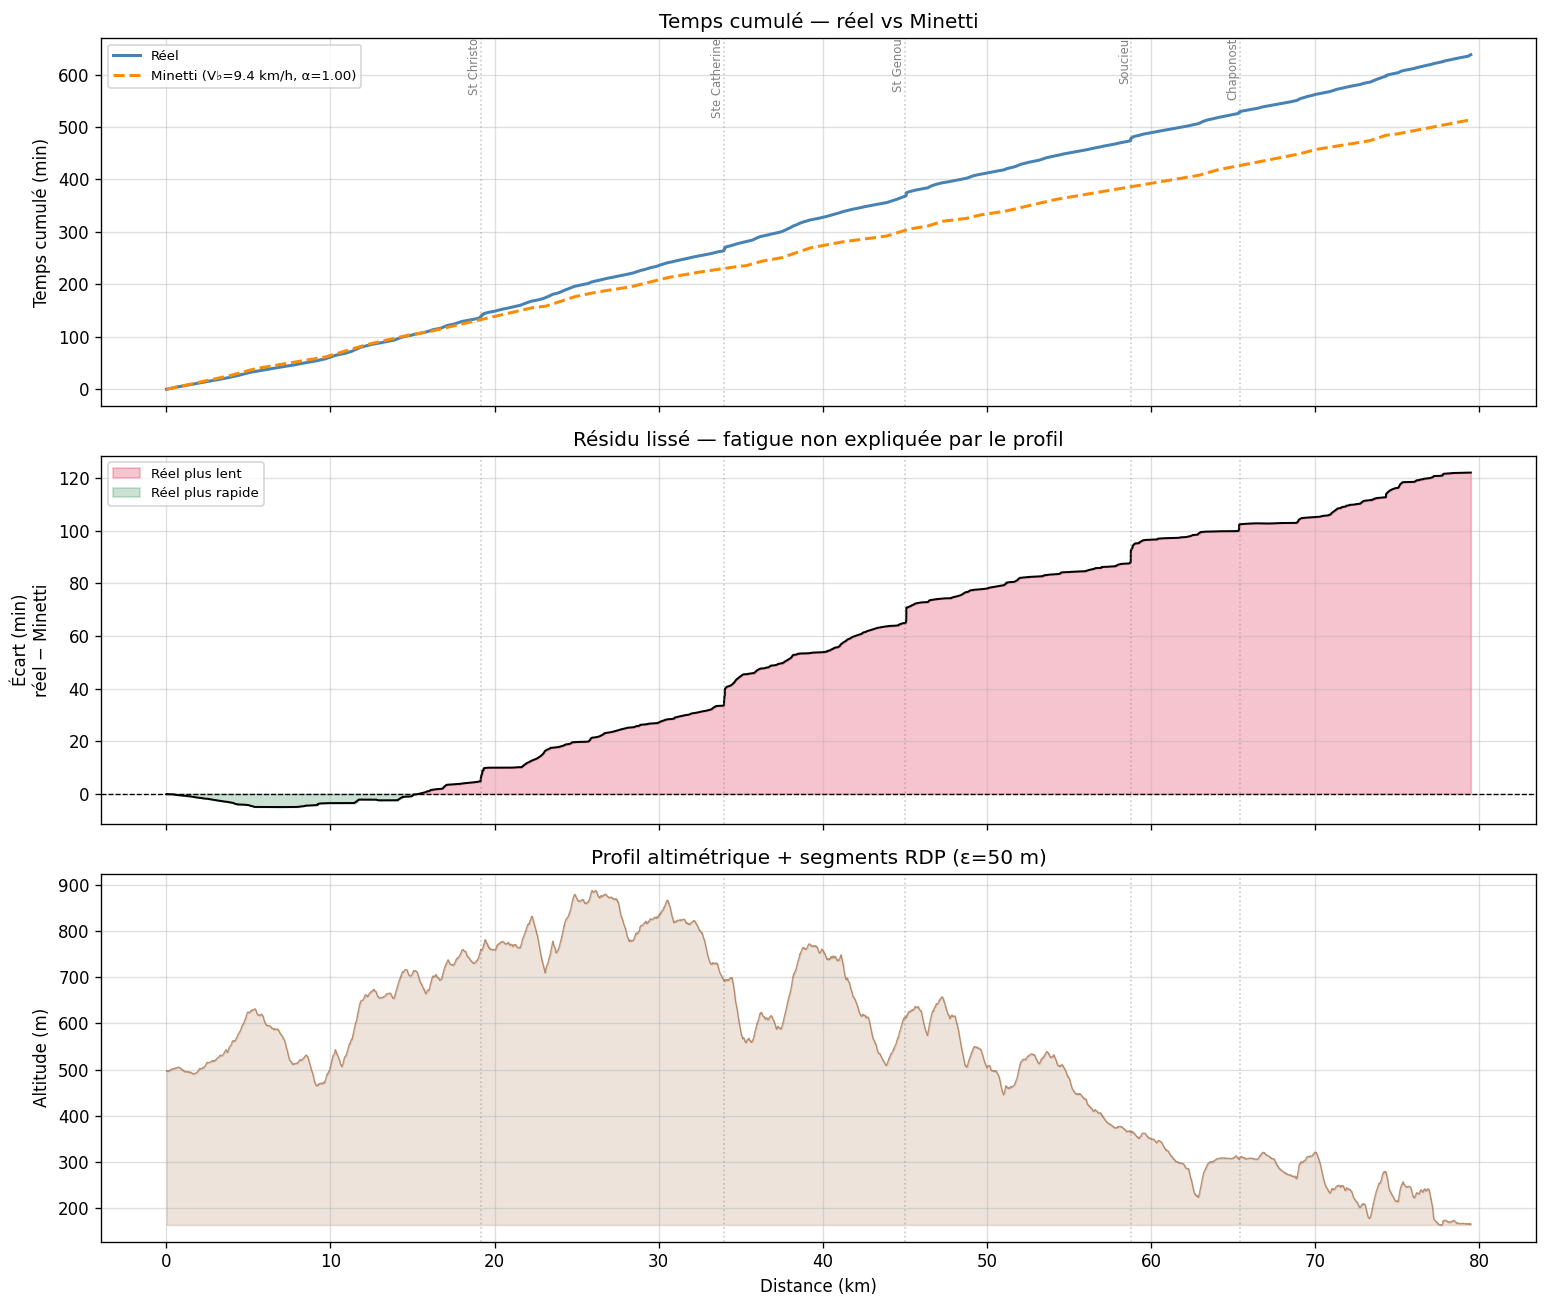

Écart total réel − Minetti : +123.8 min (+24.1%)


In [5]:
# ── 4. Graphique résiduel ─────────────────────────────────────────────────
df_real = df.dropna(subset=['dist_m', 'time_h']).copy()
df_real['time_cum_min_real'] = df_real['time_h'] * 60.0
df_real['dist_km'] = df_real['dist_m'] / 1000.0

x_pred = np.concatenate(([0.0], df_pred['seg_end_m'].to_numpy() / 1000.0))
y_pred = np.concatenate(([0.0], df_pred['time_cum_min'].to_numpy()))
time_pred_interp = np.interp(df_real['dist_km'].to_numpy(), x_pred, y_pred)
df_real['time_cum_min_pred'] = time_pred_interp
df_real['delta_min'] = df_real['time_cum_min_real'] - df_real['time_cum_min_pred']

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# Panel 1 : temps cumulé
axes[0].plot(df_real['dist_km'], df_real['time_cum_min_real'],
             color='steelblue', linewidth=1.8, label='Réel')
axes[0].plot(df_real['dist_km'], df_real['time_cum_min_pred'],
             color='darkorange', linewidth=1.8, linestyle='--',
             label=f'Minetti (V♭={V_FLAT_KMH:.1f} km/h, α={ATHLETE_FACTOR:.2f})')
for km, nom in zip(RAVITO_KM, RAVITO_NOM):
    axes[0].axvline(km, color='grey', linestyle=':', alpha=0.4, linewidth=1)
    axes[0].text(km, axes[0].get_ylim()[1], nom, fontsize=7,
                rotation=90, va='top', ha='right', color='grey')
axes[0].set_ylabel('Temps cumulé (min)')
axes[0].set_title('Temps cumulé — réel vs Minetti')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

# Panel 2 : résidu lissé
win = max(10, int(3000 / df_real['dist_m'].diff().median()))
delta_s = (pd.Series(df_real['delta_min'].values)
           .rolling(win, center=True, min_periods=5).median().values)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(df_real['dist_km'], 0, delta_s,
                     where=delta_s >= 0, color='crimson', alpha=0.25,
                     label='Réel plus lent')
axes[1].fill_between(df_real['dist_km'], 0, delta_s,
                     where=delta_s < 0, color='seagreen', alpha=0.25,
                     label='Réel plus rapide')
axes[1].plot(df_real['dist_km'], delta_s, color='black', linewidth=1.2)
for km in RAVITO_KM:
    axes[1].axvline(km, color='grey', linestyle=':', alpha=0.4, linewidth=1)
axes[1].set_ylabel('Écart (min)\nréel − Minetti')
axes[1].set_title('Résidu lissé — fatigue non expliquée par le profil')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

# Panel 3 : profil altimétrique
axes[2].fill_between(df['dist_m']/1000, df['alt_m'], df['alt_m'].min(),
                     color='saddlebrown', alpha=0.15)
axes[2].plot(df['dist_m']/1000, df['alt_m'],
             color='saddlebrown', linewidth=0.8, alpha=0.5)
for km in RAVITO_KM:
    axes[2].axvline(km, color='grey', linestyle=':', alpha=0.4, linewidth=1)
axes[2].set_xlabel('Distance (km)')
axes[2].set_ylabel('Altitude (m)')
axes[2].set_title(f'Profil altimétrique + segments RDP (ε={RDP_EPSILON_M:.0f} m)')
axes[2].grid(True, alpha=0.4)

fig.tight_layout()
plt.show()

delta_tot = df_real['time_cum_min_real'].iloc[-1] - df_pred['time_min'].sum()
print(f'Écart total réel − Minetti : {delta_tot:+.1f} min '
      f'({delta_tot/df_pred["time_min"].sum()*100:+.1f}%)')

---
## 3. Bande de confiance personnelle

> Construit à partir des courses de référence normalisées sur 0–100 %. La bande grise représente mean ± 1 std — c'est la zone où cet athlète court 'normalement'. La course cible est superposée en rouge : sortir de la bande signale une dégradation ou une amélioration inhabituelle.

> **Interprétation** :
> - Courbe cible au-dessus de la bande (GAP plus élevé) = plus lent que d'habitude
> - Courbe cible en dessous = plus rapide que d'habitude
> - Sortie en deuxième moitié = positive split plus marqué que la normale

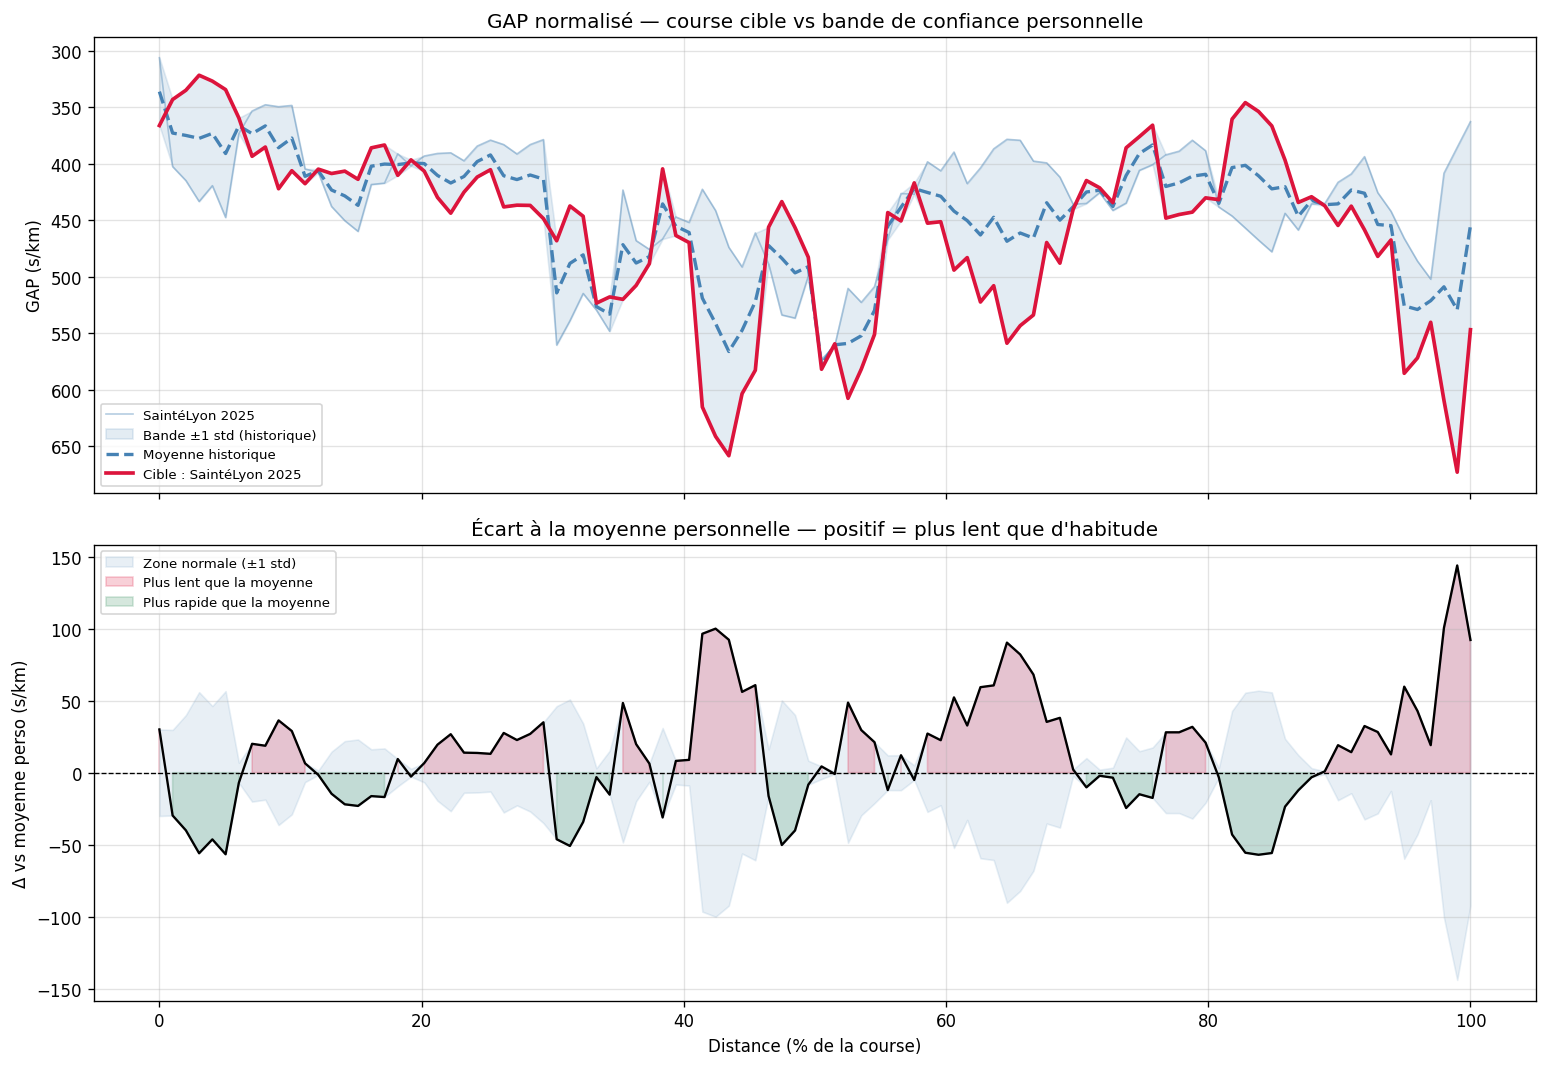

In [6]:
if len(ref_races) < 2:
    print('Bande de confiance : au moins 2 courses de référence nécessaires.')
else:
    dist_pct = np.linspace(0, 100, N_BINS)

    # Profils de référence normalisés
    ref_profiles = []
    for r in ref_races:
        norm_df = normalize_by_distance_pct(r['df'], n_bins=N_BINS,
                                            cols=['gap_s_per_km'])
        profile = norm_df['gap_s_per_km'].values.astype(float)
        profile = np.where(profile > 1200, np.nan, profile)
        # Lissage
        profile = (pd.Series(profile)
                   .rolling(5, center=True, min_periods=1).mean().values)
        ref_profiles.append(profile)

    stack = np.vstack(ref_profiles)
    mean_ref = np.nanmean(stack, axis=0)
    std_ref  = np.nanstd(stack, axis=0)

    # Profil cible normalisé
    norm_target = normalize_by_distance_pct(df, n_bins=N_BINS,
                                             cols=['gap_s_per_km'])
    profile_target = norm_target['gap_s_per_km'].values.astype(float)
    profile_target = np.where(profile_target > 1200, np.nan, profile_target)
    profile_target = (pd.Series(profile_target)
                      .rolling(5, center=True, min_periods=1).mean().values)

    fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

    # Panel 1 : profils bruts + bande
    ax0 = axes[0]
    for i, (r, prof) in enumerate(zip(ref_races, ref_profiles)):
        ax0.plot(dist_pct, prof, color='steelblue', linewidth=1.0,
                 alpha=0.4, label=r['meta']['name'] if i == 0 else '_')
    ax0.fill_between(dist_pct,
                     mean_ref - std_ref, mean_ref + std_ref,
                     color='steelblue', alpha=0.15,
                     label='Bande ±1 std (historique)')
    ax0.plot(dist_pct, mean_ref, color='steelblue', linewidth=2.0,
             linestyle='--', label='Moyenne historique')
    ax0.plot(dist_pct, profile_target, color='crimson', linewidth=2.2,
             label=f"Cible : {TARGET['label']}")
    ax0.invert_yaxis()
    ax0.set_ylabel('GAP (s/km)')
    ax0.set_title('GAP normalisé — course cible vs bande de confiance personnelle')
    ax0.legend(fontsize=8)
    ax0.grid(True, alpha=0.35)

    # Panel 2 : écart à la moyenne personnelle
    ax1 = axes[1]
    residual = profile_target - mean_ref
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.fill_between(dist_pct, -std_ref, std_ref,
                     color='steelblue', alpha=0.12,
                     label='Zone normale (±1 std)')
    ax1.fill_between(dist_pct, 0, residual,
                     where=residual >= 0, color='crimson', alpha=0.20,
                     label='Plus lent que la moyenne')
    ax1.fill_between(dist_pct, 0, residual,
                     where=residual < 0, color='seagreen', alpha=0.20,
                     label='Plus rapide que la moyenne')
    ax1.plot(dist_pct, residual, color='black', linewidth=1.4)
    ax1.set_xlabel('Distance (% de la course)')
    ax1.set_ylabel('Δ vs moyenne perso (s/km)')
    ax1.set_title('Écart à la moyenne personnelle — positif = plus lent que d\'habitude')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.35)

    fig.tight_layout()
    plt.show()

---
## 4. Modèle de déclin analytique

> Deux modèles sont proposés :
> - **Polynomial (deg. 2)** : simple, robuste, capture les accélérations finales
> - **Exponentiel** : $GAP(x) = a \cdot e^{bx} + c$ — plus réaliste physiologiquement

> Le modèle est fitté sur la moyenne des courses de référence, puis la course cible est comparée à ce modèle attendu.

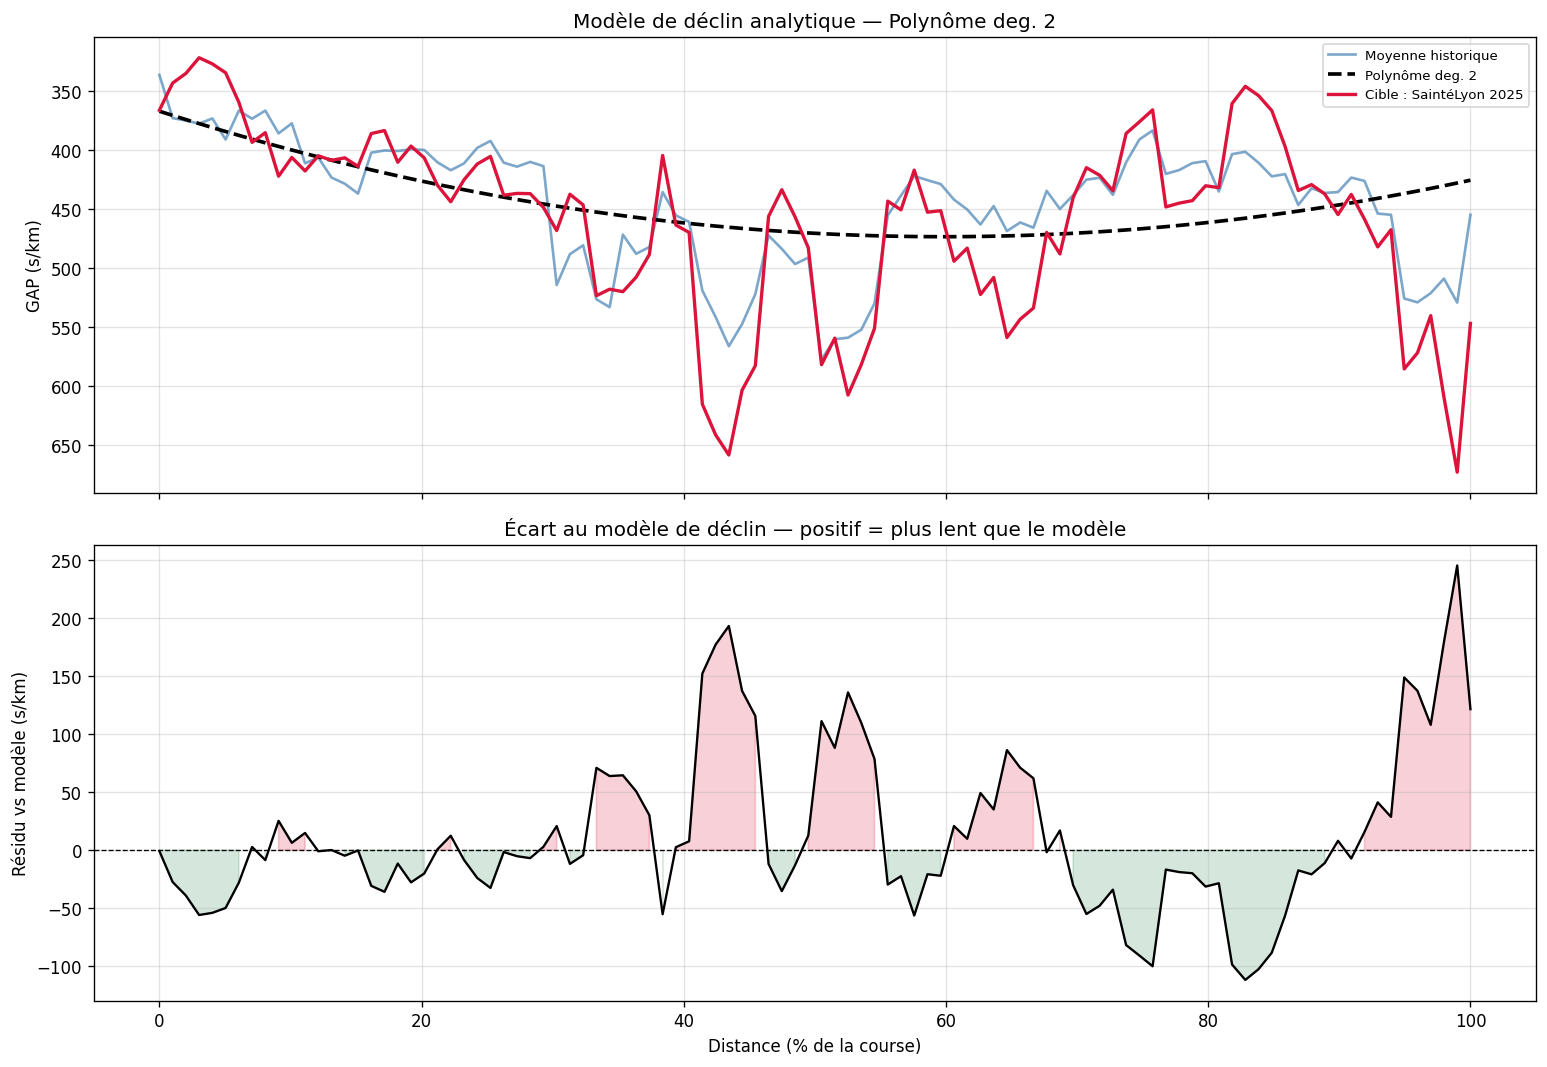

In [7]:
if len(ref_races) < 2:
    print('Modèle de déclin : au moins 2 courses de référence nécessaires.')
else:
    dist_pct = np.linspace(0, 100, N_BINS)

    # Profils de référence (déjà calculés si la cellule précédente a tourné)
    ref_profiles_local = []
    for r in ref_races:
        norm_df = normalize_by_distance_pct(r['df'], n_bins=N_BINS,
                                            cols=['gap_s_per_km'])
        p = norm_df['gap_s_per_km'].values.astype(float)
        p = np.where(p > 1200, np.nan, p)
        p = pd.Series(p).rolling(5, center=True, min_periods=1).mean().values
        ref_profiles_local.append(p)

    mean_ref_local = np.nanmean(np.vstack(ref_profiles_local), axis=0)
    valid = ~np.isnan(mean_ref_local)

    if DECAY_MODEL == 'exponential':
        def exp_decay(x, a, b, c):
            return a * np.exp(b * x / 100.0) + c
        try:
            popt, _ = curve_fit(
                exp_decay, dist_pct[valid], mean_ref_local[valid],
                p0=[50, 0.5, mean_ref_local[valid].min()],
                maxfev=5000,
            )
            fitted = exp_decay(dist_pct, *popt)
            model_label = (f'Déclin exponentiel : '
                           f'a={popt[0]:.1f}, b={popt[1]:.3f}')
        except Exception as e:
            print(f'Fit exponentiel échoué : {e} — fallback polynomial')
            coeffs = np.polyfit(dist_pct[valid], mean_ref_local[valid], DECAY_DEGREE)
            fitted = np.polyval(coeffs, dist_pct)
            model_label = f'Polynôme deg. {DECAY_DEGREE} (fallback)'
    else:
        coeffs = np.polyfit(dist_pct[valid], mean_ref_local[valid], DECAY_DEGREE)
        fitted = np.polyval(coeffs, dist_pct)
        model_label = f'Polynôme deg. {DECAY_DEGREE}'

    # Profil cible
    norm_t = normalize_by_distance_pct(df, n_bins=N_BINS, cols=['gap_s_per_km'])
    p_tgt = norm_t['gap_s_per_km'].values.astype(float)
    p_tgt = np.where(p_tgt > 1200, np.nan, p_tgt)
    p_tgt = pd.Series(p_tgt).rolling(5, center=True, min_periods=1).mean().values

    fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

    axes[0].plot(dist_pct, mean_ref_local, color='steelblue',
                 linewidth=1.6, alpha=0.7, label='Moyenne historique')
    axes[0].plot(dist_pct, fitted, color='black', linewidth=2.2,
                 linestyle='--', label=model_label)
    axes[0].plot(dist_pct, p_tgt, color='crimson', linewidth=2.0,
                 label=f"Cible : {TARGET['label']}")
    axes[0].invert_yaxis()
    axes[0].set_ylabel('GAP (s/km)')
    axes[0].set_title(f'Modèle de déclin analytique — {model_label}')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.35)

    resid = p_tgt - fitted
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].fill_between(dist_pct, 0, resid,
                         where=resid >= 0, color='crimson', alpha=0.20)
    axes[1].fill_between(dist_pct, 0, resid,
                         where=resid < 0, color='seagreen', alpha=0.20)
    axes[1].plot(dist_pct, resid, color='black', linewidth=1.4)
    axes[1].set_xlabel('Distance (% de la course)')
    axes[1].set_ylabel('Résidu vs modèle (s/km)')
    axes[1].set_title('Écart au modèle de déclin — positif = plus lent que le modèle')
    axes[1].grid(True, alpha=0.35)

    fig.tight_layout()
    plt.show()

---
## 5. Résumé chiffré — écarts aux références

> Synthèse des trois comparaisons en un tableau.

In [8]:
rows = []

# Écart à Minetti
t_reel  = kpi['duration_h'] * 60
t_minetti = df_pred['time_min'].sum()
rows.append({
    'Référence':       'Minetti pur',
    'Temps réf. (min)': round(t_minetti, 1),
    'Temps réel (min)': round(t_reel, 1),
    'Écart (min)':      round(t_reel - t_minetti, 1),
    'Écart (%)':        round((t_reel - t_minetti) / t_minetti * 100, 1),
})

# Écart à la bande de confiance personnelle (GAP médian)
if len(ref_races) >= 2:
    gap_target_med = float(np.nanmedian(profile_target))
    gap_ref_med    = float(np.nanmedian(mean_ref))
    rows.append({
        'Référence':       'Moyenne personnelle',
        'Temps réf. (min)': '—',
        'Temps réel (min)': '—',
        'Écart (min)':      '—',
        'Écart (%)':        round((gap_target_med - gap_ref_med)
                                  / gap_ref_med * 100, 1),
    })

print(pd.DataFrame(rows).to_string(index=False))

          Référence Temps réf. (min) Temps réel (min) Écart (min)  Écart (%)
        Minetti pur            514.0            637.7       123.7       24.1
Moyenne personnelle                —                —           —        1.6
